/Users/bhagya/Desktop/code/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    duration  sampling_rate       rms       zcr
0  18.910363          44100  0.205705  0.001069
1  17.241429          44100  0.231894  0.001076
2  17.299478          44100  0.198225  0.001087
3  16.617392          44100  0.275632  0.000946
4  16.762517          44100  0.396681  0.000741
        duration  sampling_rate        rms        zcr
count  25.000000           25.0  25.000000  25.000000
mean   17.163086        44100.0   0.226012   0.001467
std     2.549066            0.0   0.089329   0.000620
min     6.661837        44100.0   0.131765   0.000684
25%    16.878617        44100.0   0.159275   0.001076
50%    17.313991        44100.0   0.198225   0.001219
75%    17.444603        44100.0   0.262494   0.001870
max    23.235692        44100.0   0.432016   0.002610


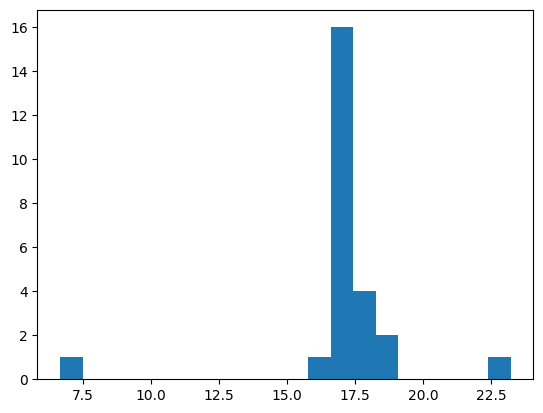

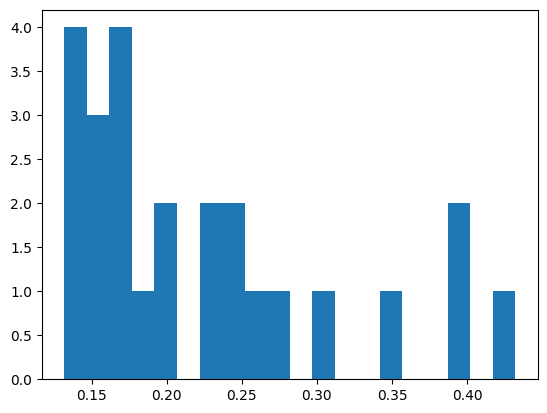

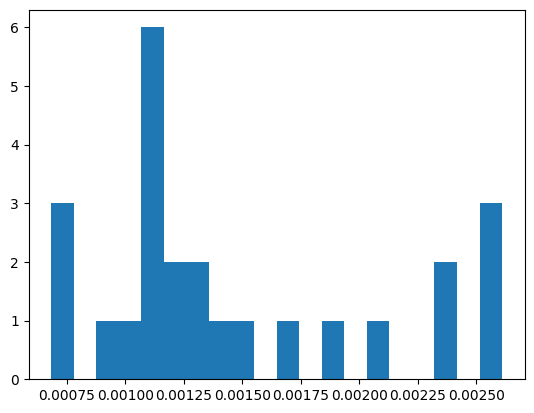

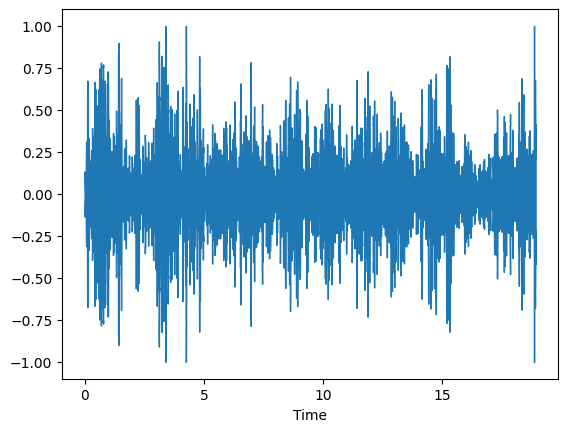

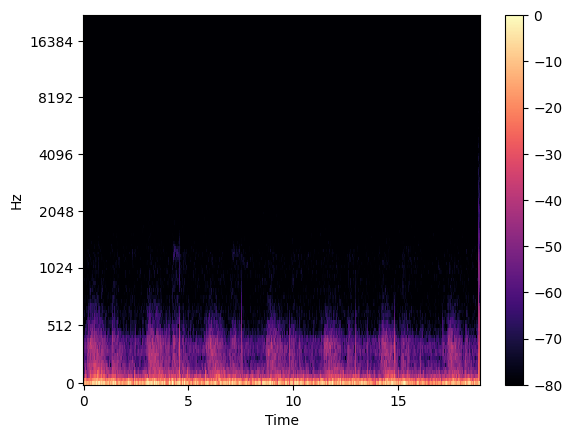

In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

base_path = "../data/normal"

files = [f for f in os.listdir(base_path) if f.endswith(".wav")]

durations = []
sr_list = []
rms_list = []
zcr_list = []

for file in files:
    path = os.path.join(base_path, file)
    y, sr = librosa.load(path, sr=None)
    durations.append(len(y)/sr)
    sr_list.append(sr)
    rms_list.append(np.mean(librosa.feature.rms(y=y)))
    zcr_list.append(np.mean(librosa.feature.zero_crossing_rate(y)))

df = pd.DataFrame({
    "duration": durations,
    "sampling_rate": sr_list,
    "rms": rms_list,
    "zcr": zcr_list
})

print(df.head())
print(df.describe())

plt.figure()
plt.hist(df["duration"], bins=20)

plt.figure()
plt.hist(df["rms"], bins=20)

plt.figure()
plt.hist(df["zcr"], bins=20)

sample_file = os.path.join(base_path, files[0])
y, sr = librosa.load(sample_file, sr=None)

plt.figure()
librosa.display.waveshow(y, sr=sr)

plt.figure()
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar()

plt.show()